# Gaitkeeper v5: Universal Adversarial Patch
### The correct formulation

Previous versions were wrong: we were optimizing the patch on a single image.
That produces an image-specific perturbation, not a universal patch.

**A universal patch must be trained across many images so it generalizes.**

```
patch = random_init()

for each training step:
    frame  = random_sample(walking_frames)   # different image every step
    patched = paste(patch, shirt_region(frame))
    loss   = YOLO_confidence(patched)        # how well does YOLO still detect?
    grad   = backprop(loss → patch_pixels)   # which pixels should change?
    patch  = patch - alpha * grad            # update patch only, not the image

# Result: one patch that fools YOLO on ANY walking frame
```

**Three attack methods compared:**
- FGSM: one step, weakest, fastest baseline
- PGD: many steps, strong
- EoT-PGD: many steps + random transforms per step, most robust (physical world)

> ⚠️ Set Runtime → T4 GPU before running.

---
## Cell 1: Install Dependencies

In [16]:
!pip install ultralytics opencv-python-headless matplotlib -q

---
## Cell 2: Imports & Config

All tunable parameters are here. Key things to know:
- `PATCH_H / PATCH_W`: fixed patch size in pixels. This is what gets printed on the shirt.
  It does NOT change per image. The patch is resized to fit the detected shirt region at inference.
- `EPSILON`: max pixel change allowed (0=no change, 1=full range). Higher = stronger but more visible.
- `NUM_FRAMES`: how many random frames to sample per training epoch.
  More frames = more universal patch = slower training.

In [17]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import torchvision.transforms.functional as TF
import random
import os
import glob
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Patch dimensions (fixed, independent of any input image) ──
# This is the actual patch that will be trained and printed.
# Resize it to match your shirt print area.
PATCH_H = 200
PATCH_W = 150

# ── Patch placement on detected person box ──
SHIRT_TOP   = 0.35   # shirt starts 35% down the person bounding box
SHIRT_BOT   = 0.65   # shirt ends 65% down
PATCH_SCALE = 0.3    # patch covers 30% of the person box width

# ── Perturbation budget ──
EPSILON = 0.3        # 0.1=subtle, 0.3=strong. Start at 0.3 for first run.

# ── FGSM: single gradient step ──
# No extra params needed.

# ── PGD: iterative gradient steps ──
PGD_STEPS = 100
PGD_ALPHA = (EPSILON / PGD_STEPS) * 2.5

# ── EoT-PGD: PGD + random transforms per step ──
EOT_STEPS = 100
EOT_ALPHA = (EPSILON / EOT_STEPS) * 2.5
EOT_N     = 8        # transforms averaged per step (more = more robust, slower)
LR        = 0.01     # Adam learning rate for EoT-PGD

# ── Loss weights (must sum to 1.0) ──
W_ENT   = 0.4        # entropy: make model uniformly confused
W_TCONF = 0.4        # targeted confidence: reduce confidence in shirt region
W_IOU   = 0.1        # iou: make model's detection not cover the shirt
W_EDGE  = 0.1        # edge: disrupt segmentation boundaries

# ── EoT transform ranges ──
ROT_RANGE        = (-20, 20)
SCALE_RANGE      = (0.85, 1.15)
BRIGHTNESS_RANGE = (0.7, 1.3)
CONTRAST_RANGE   = (0.8, 1.2)
NOISE_STD        = 0.05
BLUR_MAX         = 3
PERSP_PROB       = 0.5

YOLO_MODEL   = 'yolov8n-seg'
PERSON_CLASS = 0

print('Config loaded.')
print(f'Patch size: {PATCH_W} x {PATCH_H} px (fixed, not tied to any image)')
print(f'Epsilon: {EPSILON}')
print(f'PGD steps: {PGD_STEPS} | EoT steps: {EOT_STEPS} x {EOT_N} transforms')

Device: cuda
GPU: Tesla T4
Config loaded.
Patch size: 150 x 200 px (fixed, not tied to any image)
Epsilon: 0.3
PGD steps: 100 | EoT steps: 100 x 8 transforms


---
## Cell 3: Load YOLOv8-seg

We attack `yolov8n-seg` (nano) during development.
Swap to `yolov8x-seg` for final evaluation to test against a harder model.

The model weights are frozen throughout — we never update them.
Only the patch pixels are updated during training.

In [18]:
model = YOLO(YOLO_MODEL)
model.to(DEVICE)
torch_model = model.model
torch_model.eval()
print(f'Loaded {YOLO_MODEL}')
print('Model weights are FROZEN. Only patch pixels will be updated during training.')

Loaded yolov8n-seg
Model weights are FROZEN. Only patch pixels will be updated during training.


---
## Cell 4: Load Training Frames

**This is the key difference from v4.**

Instead of one image, we load a dataset of walking frames.
The patch will be optimized across ALL of them, making it universal.

**Option A (recommended):** Upload frames extracted from your walking videos.
Extract frames like this before uploading:
```python
import cv2
cap = cv2.VideoCapture('your_video.mp4')
os.makedirs('frames', exist_ok=True)
frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    if frame_idx % 10 == 0:  # every 10th frame
        cv2.imwrite(f'frames/frame_{frame_idx:04d}.jpg', frame)
    frame_idx += 1
```

**Option B:** Use placeholder frames for initial testing.
We download a few images with people in them.

Downloaded: frame_000.jpg
Downloaded: frame_001.jpg

Total training frames loaded: 2
Frame paths: ['/content/frames/frame_000.jpg', '/content/frames/frame_001.jpg']

Good: 2 frames. Patch will be trained across all of them.


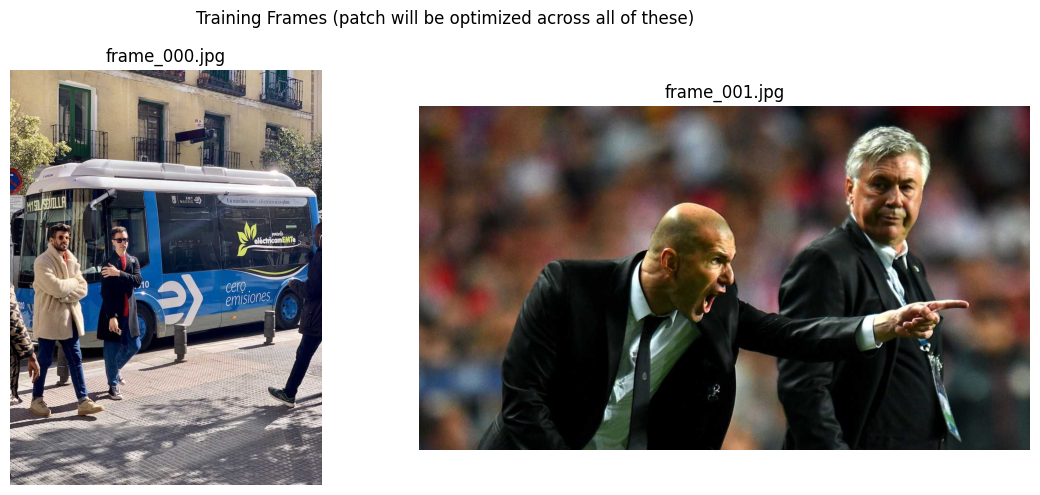

In [19]:
import urllib.request

os.makedirs('/content/frames', exist_ok=True)

# ── Option A: Upload your own walking video frames ──
# from google.colab import files
# uploaded = files.upload()
# for fname in uploaded:
#     os.rename(fname, f'/content/frames/{fname}')

# ── Option B: Download placeholder frames for initial testing ──
# These are just to verify the pipeline works.
# Replace with your actual walking frames for real results.
placeholder_urls = [
    ('https://ultralytics.com/images/bus.jpg',    'frame_000.jpg'),
    ('https://ultralytics.com/images/zidane.jpg', 'frame_001.jpg'),
]
for url, fname in placeholder_urls:
    urllib.request.urlretrieve(url, f'/content/frames/{fname}')
    print(f'Downloaded: {fname}')

# Load all frames into memory
FRAME_PATHS = sorted(glob.glob('/content/frames/*.jpg') +
                     glob.glob('/content/frames/*.png'))
print(f'\nTotal training frames loaded: {len(FRAME_PATHS)}')
print('Frame paths:', FRAME_PATHS)

if len(FRAME_PATHS) < 2:
    print('\nWARNING: Only 1 frame loaded.')
    print('The patch will still train but wont be universal.')
    print('Upload more frames from your walking videos for real results.')
else:
    print(f'\nGood: {len(FRAME_PATHS)} frames. Patch will be trained across all of them.')

# Preview all frames
fig, axes = plt.subplots(1, len(FRAME_PATHS), figsize=(6*len(FRAME_PATHS), 5))
if len(FRAME_PATHS) == 1:
    axes = [axes]
for ax, path in zip(axes, FRAME_PATHS):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(os.path.basename(path))
    ax.axis('off')
plt.suptitle('Training Frames (patch will be optimized across all of these)')
plt.tight_layout()
plt.show()

---
## Cell 5: Baseline Inference on All Frames

Run YOLO on every training frame to establish the baseline confidence we want to reduce.

=== Baseline Inference on All Training Frames ===


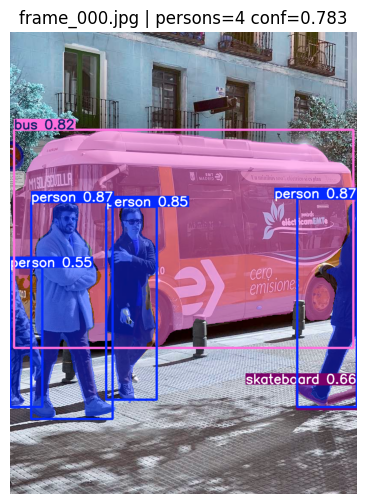

[frame_000.jpg] persons=4, avg_conf=0.7833, masks=True


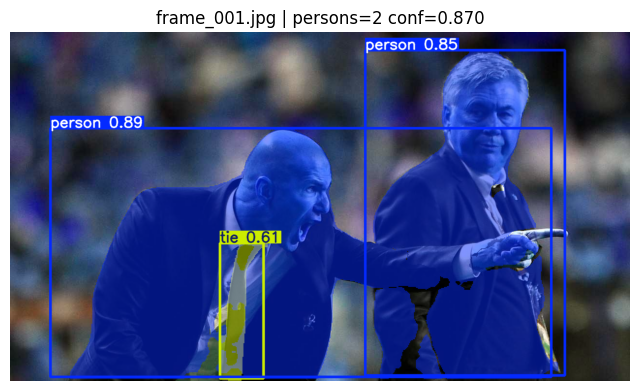

[frame_001.jpg] persons=2, avg_conf=0.8704, masks=True

Mean baseline confidence across all frames: 0.8268
Target: reduce this by as much as possible.


In [20]:
def run_inference(img_rgb, title='YOLOv8-seg', show=True):
    results  = model(img_rgb, verbose=False)
    result   = results[0]
    ann      = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    confs    = [float(result.boxes.conf[i])
                for i, c in enumerate(result.boxes.cls)
                if int(c) == PERSON_CLASS] if result.boxes is not None else []
    avg_conf  = float(np.mean(confs)) if confs else 0.0
    has_masks = result.masks is not None
    if show:
        plt.figure(figsize=(8,6))
        plt.imshow(ann)
        plt.title(f'{title} | persons={len(confs)} conf={avg_conf:.3f}')
        plt.axis('off')
        plt.show()
    print(f'[{title}] persons={len(confs)}, avg_conf={avg_conf:.4f}, masks={has_masks}')
    return results, avg_conf

# Run baseline on all frames
print('=== Baseline Inference on All Training Frames ===')
baseline_data = {}   # frame_path -> (results, avg_conf)
all_baseline_confs = []

for path in FRAME_PATHS:
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    results, conf = run_inference(img_rgb, title=os.path.basename(path))
    baseline_data[path] = (img_rgb, results, conf)
    if conf > 0:
        all_baseline_confs.append(conf)

baseline_conf = float(np.mean(all_baseline_confs)) if all_baseline_confs else 0.0
print(f'\nMean baseline confidence across all frames: {baseline_conf:.4f}')
print(f'Target: reduce this by as much as possible.')

---
## Cell 6: Helper Functions

Standard utilities for image conversion, shirt box detection, and patch compositing.

Key function: `get_shirt_box()` finds the shirt region on a detected person.
It returns pixel coordinates (x1, y1, x2, y2) of where to paste the patch.

In [21]:
def img_to_tensor(img_rgb):
    """HxWx3 uint8 numpy -> 1x3xHxW float32 on DEVICE"""
    t = torch.from_numpy(img_rgb).float() / 255.0
    return t.permute(2,0,1).unsqueeze(0).to(DEVICE)

def tensor_to_img(t):
    """1x3xHxW float tensor -> HxWx3 uint8 numpy"""
    t = t.squeeze(0).permute(1,2,0).detach().cpu()
    return (t.clamp(0,1)*255).byte().numpy()

def get_shirt_box(results, img_h, img_w):
    """
    Find the largest detected person and return the shirt region bounding box.
    Shirt = upper-center portion of the person bounding box.
    Returns (x1, y1, x2, y2) in pixel coords, or None if no person found.
    """
    result = results[0]
    if result.boxes is None:
        return None
    best_box, best_area = None, 0
    for i, cls in enumerate(result.boxes.cls):
        if int(cls) == PERSON_CLASS:
            box  = result.boxes.xyxy[i].cpu().numpy()
            area = (box[2]-box[0])*(box[3]-box[1])
            if area > best_area:
                best_area, best_box = area, box
    if best_box is None:
        return None
    bx1,by1,bx2,by2 = best_box
    bw,bh = bx2-bx1, by2-by1
    cx = (bx1+bx2)/2
    x1 = max(0,       int(cx - bw*PATCH_SCALE/2))
    x2 = min(img_w-1, int(cx + bw*PATCH_SCALE/2))
    y1 = max(0,       int(by1 + bh*SHIRT_TOP))
    y2 = min(img_h-1, int(by1 + bh*SHIRT_BOT))
    if x2<=x1 or y2<=y1:
        return None
    return (x1,y1,x2,y2)

def apply_patch(img_tensor, patch, box):
    """
    Paste patch onto img_tensor at the shirt region defined by box.
    patch is resized to fit the box region.
    img_tensor: [1,3,H,W]  patch: [1,3,PATCH_H,PATCH_W]  box: (x1,y1,x2,y2)
    """
    x1,y1,x2,y2 = box
    ph,pw = y2-y1, x2-x1
    if ph<=0 or pw<=0:
        return img_tensor
    resized = F.interpolate(patch, size=(ph,pw), mode='bilinear', align_corners=False)
    out = img_tensor.clone()
    out[:,:,y1:y2,x1:x2] = resized
    return out

def get_raw_output(img_tensor):
    """Run YOLO backbone returning raw logits for backprop."""
    resized = F.interpolate(img_tensor, size=(640,640), mode='bilinear', align_corners=False)
    return torch_model(resized)

print('Helpers loaded.')

Helpers loaded.


---
## Cell 7: Initialize the Universal Patch

The patch is a fixed-size tensor `[1, 3, PATCH_H, PATCH_W]` initialized with
random noise near gray (range 0.4-0.6).

Starting near gray (not pure random 0-1) gives the optimizer room to move
pixel values in both directions from the start.

This patch tensor is what gets updated during training — NOT the input images.

Universal patch initialized.
Shape: [1, 3, 200, 150]
Pixel range: [0.40, 0.60]
This patch will be optimized across 2 training frames.


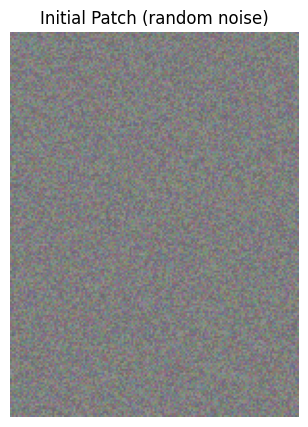

In [22]:
# Initialize patch as random noise near gray
# Shape: [1, 3, PATCH_H, PATCH_W] — fixed size, independent of any input image
patch_init = (torch.rand(1, 3, PATCH_H, PATCH_W, device=DEVICE) * 0.2 + 0.4).clamp(0,1)
print(f'Universal patch initialized.')
print(f'Shape: {list(patch_init.shape)}')
print(f'Pixel range: [{patch_init.min():.2f}, {patch_init.max():.2f}]')
print(f'This patch will be optimized across {len(FRAME_PATHS)} training frames.')

# Visualize initial patch
p = patch_init.squeeze(0).permute(1,2,0).cpu().numpy()
p = (p*255).astype(np.uint8)
plt.figure(figsize=(4,5))
plt.imshow(cv2.resize(p,(150,200),interpolation=cv2.INTER_NEAREST))
plt.title('Initial Patch (random noise)')
plt.axis('off')
plt.show()

---
## Cell 8: EoT Transform Suite

Used only in EoT-PGD. Each training step averages gradients over `EOT_N`
random draws from this transform distribution.

This simulates how the patch looks different in the real world:
- **Brightness/Contrast**: lighting changes throughout the day
- **Rotation**: person turning, camera angle changing
- **Scale**: different distances from camera
- **Perspective warp**: fabric curvature on a 3D body (most important for shirts)
- **Motion blur**: person walking, camera motion
- **Gaussian noise**: sensor and compression artifacts

In [23]:
def apply_motion_blur(tensor, max_kernel=3):
    k = random.choice([1,3]) if max_kernel>=3 else 1
    if k==1: return tensor
    kernel = torch.zeros(k,k,device=tensor.device)
    if random.random()>0.5:
        kernel[k//2,:] = 1.0/k
    else:
        kernel[:,k//2] = 1.0/k
    kernel = kernel.view(1,1,k,k).expand(3,1,k,k)
    return F.conv2d(tensor, kernel, padding=k//2, groups=3)

def apply_perspective_warp(tensor):
    _,_,H,W = tensor.shape
    d   = 0.05
    src = np.float32([[0,0],[W,0],[W,H],[0,H]])
    dst = np.float32([
        [random.uniform(0,d*W),   random.uniform(0,d*H)],
        [W-random.uniform(0,d*W), random.uniform(0,d*H)],
        [W-random.uniform(0,d*W), H-random.uniform(0,d*H)],
        [random.uniform(0,d*W),   H-random.uniform(0,d*H)],
    ])
    M      = cv2.getPerspectiveTransform(src, dst)
    img_np = tensor_to_img(tensor)
    warped = cv2.warpPerspective(img_np, M, (W,H))
    return img_to_tensor(warped)

def random_eot_transform(img_tensor):
    """Apply a random combination of real-world transforms to the patched image."""
    t = img_tensor.clone()
    # Brightness
    t = t * random.uniform(*BRIGHTNESS_RANGE)
    # Contrast
    mean = t.mean(dim=[2,3], keepdim=True)
    t = (t-mean)*random.uniform(*CONTRAST_RANGE)+mean
    # Rotation
    t = TF.rotate(t.squeeze(0), random.uniform(*ROT_RANGE)).unsqueeze(0)
    # Scale
    scale = random.uniform(*SCALE_RANGE)
    _,_,H,W = t.shape
    nh,nw = int(H*scale), int(W*scale)
    ts = F.interpolate(t, size=(nh,nw), mode='bilinear', align_corners=False)
    if scale < 1.0:
        ph2,pw2 = (H-nh)//2, (W-nw)//2
        t = F.pad(ts,(pw2,W-nw-pw2,ph2,H-nh-ph2))
    else:
        sh,sw = (nh-H)//2, (nw-W)//2
        t = ts[:,:,sh:sh+H,sw:sw+W]
    # Perspective warp (simulates fabric curvature)
    if random.random()<PERSP_PROB:
        t = apply_perspective_warp(t)
    # Motion blur
    t = apply_motion_blur(t, BLUR_MAX)
    # Gaussian noise
    t = t + torch.randn_like(t)*NOISE_STD
    return t.clamp(0,1)

print('EoT transforms loaded.')

EoT transforms loaded.


---
## Cell 9: Loss Functions

Four components, all oriented so **LOWER = better attack**:

| Component | Weight | What it does |
|---|---|---|
| `entropy_loss` | 0.4 | Maximize model confusion across all 80 classes |
| `targeted_conf_loss` | 0.4 | Minimize confidence specifically in the shirt region anchors |
| `iou_loss` | 0.1 | Make the detection not overlap the shirt region |
| `edge_loss` | 0.1 | Disrupt segmentation boundary sharpness |

**Why targeted_conf matters:**
The model outputs 8400 anchor predictions. Most are background.
We find the anchors whose centers fall inside the shirt bounding box
and minimize confidence specifically there — not wasted on background anchors.

In [24]:
ANCHOR_CENTERS = None

def get_anchor_centers(device):
    """
    YOLOv8 uses 3 detection scales:
      stride 8  -> 80x80 = 6400 anchors
      stride 16 -> 40x40 = 1600 anchors
      stride 32 -> 20x20 =  400 anchors
      total = 8400 anchors
    Returns center (cx,cy) normalized to [0,1] for all 8400 anchors.
    """
    centers = []
    for stride in [8,16,32]:
        grid = 640//stride
        for row in range(grid):
            for col in range(grid):
                centers.append(((col+0.5)/grid, (row+0.5)/grid))
    return torch.tensor(centers, device=device)  # [8400, 2]

def extract_preds(raw_output):
    """
    Extract scores and boxes from YOLOv8 dict output.
    Handles dict format: {'scores':[1,80,8400], 'boxes':[1,64,8400], ...}
    Also handles fallback tensor formats from older ultralytics versions.
    """
    payload = raw_output[0] if isinstance(raw_output,(tuple,list)) else raw_output
    if isinstance(payload, dict):
        return payload['scores'], payload['boxes']
    # Fallback: bare tensor
    if isinstance(payload, torch.Tensor):
        p = payload
        if p.dim()==4: p=p.flatten(2)
        if p.shape[1]>p.shape[2]: p=p.permute(0,2,1)
        return p[:,4:84,:], p
    raise ValueError(f'Unknown output format: {type(payload)}')

def entropy_loss(raw_output):
    scores,_ = extract_preds(raw_output)              # [1,80,8400]
    probs    = torch.softmax(scores, dim=1)
    entropy  = -(probs*(probs+1e-8).log()).sum(dim=1) # [1,8400]
    return -entropy.mean()   # minimize = maximize entropy

def targeted_conf_loss(raw_output, shirt_box, img_shape):
    """Minimize confidence for anchors inside the shirt region only."""
    global ANCHOR_CENTERS
    scores,_ = extract_preds(raw_output)
    H,W      = img_shape
    x1,y1,x2,y2 = shirt_box
    if ANCHOR_CENTERS is None:
        ANCHOR_CENTERS = get_anchor_centers(scores.device)
    # Normalize shirt box to [0,1]
    sx1,sy1,sx2,sy2 = x1/W, y1/H, x2/W, y2/H
    cx,cy = ANCHOR_CENTERS[:,0], ANCHOR_CENTERS[:,1]
    in_shirt = (cx>=sx1)&(cx<=sx2)&(cy>=sy1)&(cy<=sy2)
    if in_shirt.sum()==0:
        # Fallback: use all anchors if shirt region has none
        return torch.sigmoid(scores.amax(dim=1)).mean()
    max_scores_in_shirt = scores[0].amax(dim=0)[in_shirt]
    return torch.sigmoid(max_scores_in_shirt).mean()

def iou_loss(raw_output, shirt_box, img_shape):
    """Minimize detection strength inside the shirt region."""
    global ANCHOR_CENTERS
    scores,_ = extract_preds(raw_output)
    H,W      = img_shape
    x1,y1,x2,y2 = shirt_box
    if ANCHOR_CENTERS is None:
        ANCHOR_CENTERS = get_anchor_centers(scores.device)
    sx1,sy1,sx2,sy2 = x1/W, y1/H, x2/W, y2/H
    cx,cy    = ANCHOR_CENTERS[:,0], ANCHOR_CENTERS[:,1]
    in_shirt = (cx>=sx1)&(cx<=sx2)&(cy>=sy1)&(cy<=sy2)
    max_scores = scores[0].amax(dim=0)
    if in_shirt.sum()==0:
        return torch.tensor(0.0, device=scores.device)
    return torch.sigmoid(max_scores[in_shirt]).mean()

def edge_loss(raw_output):
    """Maximize variance of confidence = disrupt segmentation edges."""
    scores,_ = extract_preds(raw_output)
    return -torch.sigmoid(scores.amax(dim=1)).var()

def combined_loss(raw_output, shirt_box, img_shape):
    """
    Multi-objective loss. Keys in returned dict: ent, tconf, iou, edge, total.
    All components: LOWER = better attack.
    """
    L_ent   = entropy_loss(raw_output)
    L_tconf = targeted_conf_loss(raw_output, shirt_box, img_shape)
    L_iou   = iou_loss(raw_output, shirt_box, img_shape)
    L_edge  = edge_loss(raw_output)
    total   = W_ENT*L_ent + W_TCONF*L_tconf + W_IOU*L_iou + W_EDGE*L_edge
    return total, {
        'ent':   L_ent.item(),
        'tconf': L_tconf.item(),
        'iou':   L_iou.item(),
        'edge':  L_edge.item(),
        'total': total.item()
    }

# Precompute anchor centers
ANCHOR_CENTERS = get_anchor_centers(DEVICE)

# Quick sanity check on first frame
print('Running sanity check on loss functions...')
_img_rgb = cv2.cvtColor(cv2.imread(FRAME_PATHS[0]), cv2.COLOR_BGR2RGB)
_t  = img_to_tensor(_img_rgb)
_r  = F.interpolate(_t, size=(640,640), mode='bilinear', align_corners=False)
torch_model.train()
with torch.no_grad():
    _out = torch_model(_r)
torch_model.eval()

_sc,_bx = extract_preds(_out)
print(f'scores: {list(_sc.shape)}  <- should be [1,80,8400]')
print(f'boxes:  {list(_bx.shape)}  <- should be [1,64,8400]')

_res, _conf = baseline_data[FRAME_PATHS[0]][1], baseline_data[FRAME_PATHS[0]][2]
_box = get_shirt_box(_res, _img_rgb.shape[0], _img_rgb.shape[1])
if _box:
    _tc = targeted_conf_loss(_out, _box, (_img_rgb.shape[0],_img_rgb.shape[1]))
    _iu = iou_loss(_out, _box, (_img_rgb.shape[0],_img_rgb.shape[1]))
    print(f'targeted_conf on clean frame: {_tc.item():.4f}')
    print(f'iou_loss on clean frame:      {_iu.item():.4f}')
else:
    print('WARNING: No shirt box found on first frame.')
print('Loss functions ready.')

Running sanity check on loss functions...
scores: [1, 80, 8400]  <- should be [1,80,8400]
boxes:  [1, 64, 8400]  <- should be [1,64,8400]
targeted_conf on clean frame: 0.0207
iou_loss on clean frame:      0.0207
Loss functions ready.


---
## Cell 10: Attack 1 — FGSM (Universal)

Single gradient step averaged across all training frames.

For each frame:
1. Paste current patch onto shirt region
2. Run YOLO, compute loss
3. Accumulate gradient

Then take one big step in the direction that reduces confidence across all frames.

This is the weakest attack but runs in seconds and proves the pipeline works.

Running Universal FGSM...
FGSM: averaged gradients over 2 frames.

Evaluating FGSM patch on all frames...


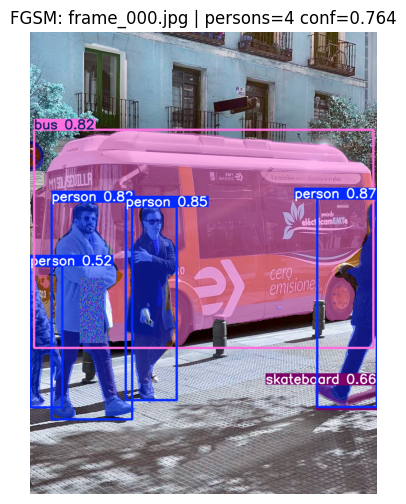

[FGSM: frame_000.jpg] persons=4, avg_conf=0.7641, masks=True


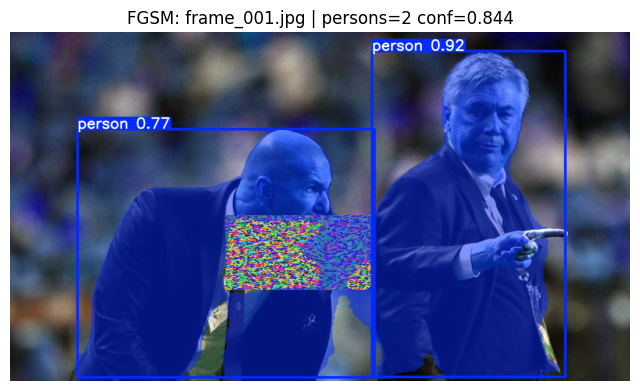

[FGSM: frame_001.jpg] persons=2, avg_conf=0.8436, masks=True

Mean baseline conf: 0.8268
Mean FGSM conf:     0.8038
Drop: 0.0230 (2.8%)


In [25]:
def fgsm_universal(patch_init, frame_paths, epsilon):
    """
    Universal FGSM: single gradient step averaged across all training frames.
    patch_init: [1,3,PATCH_H,PATCH_W]
    Returns: adversarial patch [1,3,PATCH_H,PATCH_W]
    """
    patch     = patch_init.clone().requires_grad_(True)
    accum_grad = torch.zeros_like(patch)
    n_valid    = 0

    torch_model.train()
    for path in frame_paths:
        img_rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        results = baseline_data[path][1]
        box     = get_shirt_box(results, img_rgb.shape[0], img_rgb.shape[1])
        if box is None:
            continue

        img_tensor  = img_to_tensor(img_rgb)
        img_patched = apply_patch(img_tensor, patch, box)
        raw_out     = get_raw_output(img_patched)
        loss, _     = combined_loss(raw_out, box, (img_rgb.shape[0], img_rgb.shape[1]))
        loss.backward()

        if patch.grad is not None:
            accum_grad = accum_grad + patch.grad.data
            n_valid   += 1
            patch.grad.data.zero_()

    torch_model.eval()

    if n_valid == 0:
        print('WARNING: No valid shirt boxes found in any frame.')
        return patch_init.clone()

    avg_grad  = accum_grad / n_valid
    with torch.no_grad():
        patch_adv = patch - epsilon * avg_grad.sign()
        patch_adv = patch_adv.clamp(0,1)

    print(f'FGSM: averaged gradients over {n_valid} frames.')
    return patch_adv.detach()


print('Running Universal FGSM...')
patch_fgsm = fgsm_universal(patch_init, FRAME_PATHS, EPSILON)

# Evaluate on all frames
print('\nEvaluating FGSM patch on all frames...')
fgsm_confs = []
for path in FRAME_PATHS:
    img_rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    results = baseline_data[path][1]
    box     = get_shirt_box(results, img_rgb.shape[0], img_rgb.shape[1])
    if box is None:
        continue
    img_tensor  = img_to_tensor(img_rgb)
    img_adv     = apply_patch(img_tensor, patch_fgsm, box)
    img_adv_np  = tensor_to_img(img_adv)
    _, conf = run_inference(img_adv_np, f'FGSM: {os.path.basename(path)}')
    fgsm_confs.append(conf)

fgsm_conf = float(np.mean(fgsm_confs)) if fgsm_confs else 0.0
print(f'\nMean baseline conf: {baseline_conf:.4f}')
print(f'Mean FGSM conf:     {fgsm_conf:.4f}')
print(f'Drop: {baseline_conf-fgsm_conf:.4f} ({(baseline_conf-fgsm_conf)/baseline_conf*100:.1f}%)')

---
## Cell 11: Attack 2 — PGD (Universal)

Iterative version of FGSM. Each step:
1. For every training frame, compute gradient of loss w.r.t. patch
2. Average gradients across all frames
3. Take one small step, clip to epsilon ball
4. Repeat

The patch sees every frame every step, so it cannot overfit to any one image.
This is what makes it universal.

Running Universal PGD...
  Step [20/100] avg_loss=-1.3038 over 2 frames
  Step [40/100] avg_loss=-1.3236 over 2 frames
  Step [60/100] avg_loss=-1.3353 over 2 frames
  Step [80/100] avg_loss=-1.3411 over 2 frames
  Step [100/100] avg_loss=-1.3464 over 2 frames

Evaluating PGD patch on all frames...


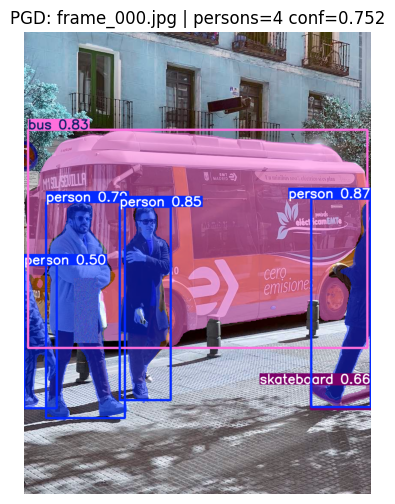

[PGD: frame_000.jpg] persons=4, avg_conf=0.7517, masks=True


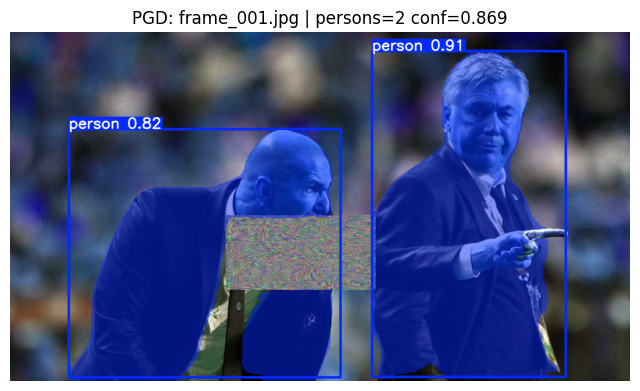

[PGD: frame_001.jpg] persons=2, avg_conf=0.8689, masks=True


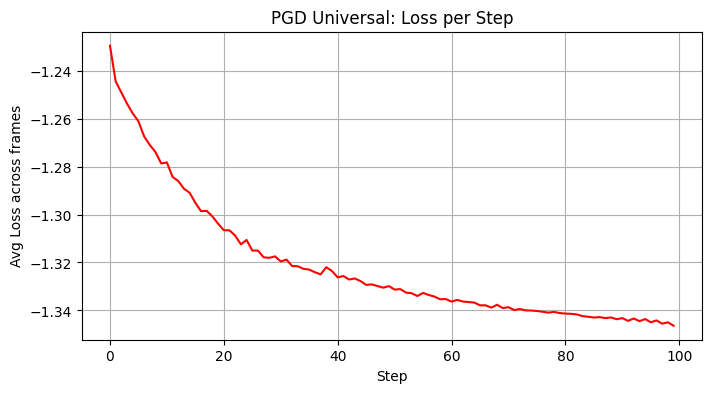


Mean baseline conf: 0.8268
Mean PGD conf:      0.8103
Drop: 0.0166 (2.0%)


In [26]:
def pgd_universal(patch_init, frame_paths, epsilon, alpha, steps, verbose=True):
    """
    Universal PGD: iterative gradient steps averaged across all training frames.
    patch_init: [1,3,PATCH_H,PATCH_W]
    Returns: best adversarial patch, loss history
    """
    patch      = patch_init.clone()
    patch_orig = patch_init.clone().detach()
    loss_history = []

    torch_model.train()
    for step in range(steps):
        patch      = patch.detach().requires_grad_(True)
        accum_grad = torch.zeros_like(patch)
        step_losses = []
        n_valid = 0

        for path in frame_paths:
            img_rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
            results = baseline_data[path][1]
            box     = get_shirt_box(results, img_rgb.shape[0], img_rgb.shape[1])
            if box is None:
                continue
            img_tensor  = img_to_tensor(img_rgb)
            img_patched = apply_patch(img_tensor, patch, box)
            raw_out     = get_raw_output(img_patched)
            loss, comps = combined_loss(raw_out, box, (img_rgb.shape[0], img_rgb.shape[1]))
            loss.backward()
            step_losses.append(comps['total'])
            if patch.grad is not None:
                accum_grad = accum_grad + patch.grad.data
                n_valid   += 1
                patch.grad.data.zero_()

        if n_valid == 0:
            continue

        avg_loss = np.mean(step_losses)
        loss_history.append(avg_loss)

        with torch.no_grad():
            avg_grad = accum_grad / n_valid
            patch    = patch - alpha * avg_grad.sign()
            delta    = (patch - patch_orig).clamp(-epsilon, epsilon)
            patch    = (patch_orig + delta).clamp(0,1)

        if verbose and (step+1) % 20 == 0:
            print(f'  Step [{step+1}/{steps}] avg_loss={avg_loss:+.4f} over {n_valid} frames')

    torch_model.eval()
    return patch.detach(), loss_history


print('Running Universal PGD...')
patch_pgd, pgd_history = pgd_universal(
    patch_init, FRAME_PATHS, EPSILON, PGD_ALPHA, PGD_STEPS
)

# Evaluate
print('\nEvaluating PGD patch on all frames...')
pgd_confs = []
for path in FRAME_PATHS:
    img_rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    results = baseline_data[path][1]
    box     = get_shirt_box(results, img_rgb.shape[0], img_rgb.shape[1])
    if box is None:
        continue
    img_adv_np = tensor_to_img(apply_patch(img_to_tensor(img_rgb), patch_pgd, box))
    _, conf = run_inference(img_adv_np, f'PGD: {os.path.basename(path)}')
    pgd_confs.append(conf)

pgd_conf = float(np.mean(pgd_confs)) if pgd_confs else 0.0

plt.figure(figsize=(8,4))
plt.plot(pgd_history, color='red')
plt.xlabel('Step'), plt.ylabel('Avg Loss across frames')
plt.title('PGD Universal: Loss per Step'), plt.grid(True), plt.show()

print(f'\nMean baseline conf: {baseline_conf:.4f}')
print(f'Mean PGD conf:      {pgd_conf:.4f}')
print(f'Drop: {baseline_conf-pgd_conf:.4f} ({(baseline_conf-pgd_conf)/baseline_conf*100:.1f}%)')

---
## Cell 12: Attack 3 — EoT-PGD (Universal + Robust)

The strongest attack. Combines:
- **Universal**: gradients averaged across all training frames
- **EoT**: each frame is randomly transformed before computing the gradient

This means the patch is optimized to fool YOLO across:
- Many different input images (universal)
- Many different viewing conditions (robust to real-world conditions)

This is the patch you want to print on the shirt.

Running Universal EoT-PGD...
100 steps x 8 transforms x 2 frames = 1600 forward passes
  Step [20/100] total=-1.3852 tconf=0.0094 ent=-3.4744 iou=0.0094
  Step [40/100] total=-1.3963 tconf=0.0097 ent=-3.5023 iou=0.0097
  Step [60/100] total=-1.3998 tconf=0.0093 ent=-3.5109 iou=0.0093
  Step [80/100] total=-1.4081 tconf=0.0081 ent=-3.5300 iou=0.0081
  Step [100/100] total=-1.3998 tconf=0.0082 ent=-3.5092 iou=0.0082

Evaluating EoT-PGD patch on all frames...


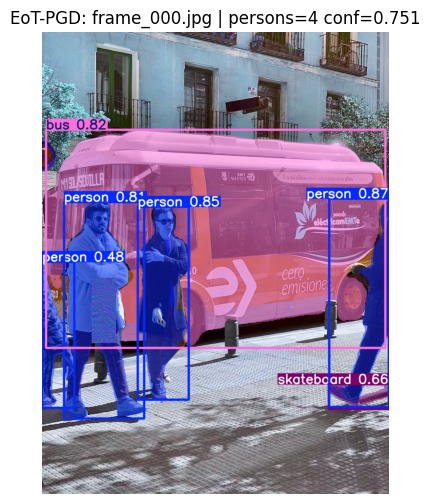

[EoT-PGD: frame_000.jpg] persons=4, avg_conf=0.7507, masks=True


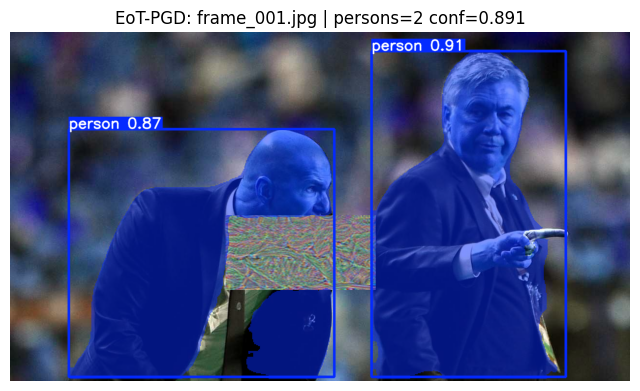

[EoT-PGD: frame_001.jpg] persons=2, avg_conf=0.8907, masks=True

Mean baseline conf: 0.8268
Mean EoT-PGD conf:  0.8207
Drop: 0.0061 (0.7%)


In [27]:
def eot_pgd_universal(patch_init, frame_paths, epsilon, alpha, steps, eot_n, verbose=True):
    """
    Universal EoT-PGD: PGD with random transforms, averaged across all frames.
    patch_init: [1,3,PATCH_H,PATCH_W]
    Returns: best adversarial patch, loss history dict
    """
    patch      = patch_init.clone().requires_grad_(True)
    patch_orig = patch_init.clone().detach()
    optimizer  = torch.optim.Adam([patch], lr=LR)

    history    = {'total':[], 'ent':[], 'tconf':[], 'iou':[], 'edge':[]}
    best_loss  = float('inf')
    best_patch = patch.detach().clone()

    torch_model.train()
    for step in range(steps):
        optimizer.zero_grad()
        step_comps  = {'total':0,'ent':0,'tconf':0,'iou':0,'edge':0}
        total_loss  = torch.tensor(0.0, device=DEVICE)
        n_valid     = 0

        for path in frame_paths:
            img_rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
            results = baseline_data[path][1]
            box     = get_shirt_box(results, img_rgb.shape[0], img_rgb.shape[1])
            if box is None:
                continue

            img_tensor = img_to_tensor(img_rgb)

            for _ in range(eot_n):
                img_patched     = apply_patch(img_tensor, patch, box)
                img_transformed = random_eot_transform(img_patched)
                raw_out         = get_raw_output(img_transformed)
                loss, comps     = combined_loss(raw_out, box, (img_rgb.shape[0], img_rgb.shape[1]))
                total_loss      = total_loss + loss
                for k in comps:
                    step_comps[k] += comps[k]
                n_valid += 1

        if n_valid == 0:
            continue

        avg_loss = total_loss / n_valid
        avg_loss.backward()
        torch.nn.utils.clip_grad_norm_([patch], max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            delta      = patch.data - patch_orig
            delta      = delta.clamp(-epsilon, epsilon)
            patch.data = (patch_orig + delta).clamp(0,1)

        for k in history:
            history[k].append(step_comps[k] / n_valid)

        if avg_loss.item() < best_loss:
            best_loss  = avg_loss.item()
            best_patch = patch.detach().clone()

        if verbose and (step+1) % 20 == 0:
            ec = {k: step_comps[k]/n_valid for k in step_comps}
            print(f'  Step [{step+1}/{steps}] '
                  f'total={ec["total"]:+.4f} '
                  f'tconf={ec["tconf"]:.4f} '
                  f'ent={ec["ent"]:.4f} '
                  f'iou={ec["iou"]:.4f}')

    torch_model.eval()
    return best_patch, history


n_passes = EOT_STEPS * EOT_N * len(FRAME_PATHS)
print(f'Running Universal EoT-PGD...')
print(f'{EOT_STEPS} steps x {EOT_N} transforms x {len(FRAME_PATHS)} frames = {n_passes} forward passes')

patch_eot, eot_history = eot_pgd_universal(
    patch_init, FRAME_PATHS, EPSILON, EOT_ALPHA, EOT_STEPS, EOT_N
)

# Evaluate
print('\nEvaluating EoT-PGD patch on all frames...')
eot_confs = []
for path in FRAME_PATHS:
    img_rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    results = baseline_data[path][1]
    box     = get_shirt_box(results, img_rgb.shape[0], img_rgb.shape[1])
    if box is None:
        continue
    img_adv_np = tensor_to_img(apply_patch(img_to_tensor(img_rgb), patch_eot, box))
    _, conf = run_inference(img_adv_np, f'EoT-PGD: {os.path.basename(path)}')
    eot_confs.append(conf)

eot_conf = float(np.mean(eot_confs)) if eot_confs else 0.0

print(f'\nMean baseline conf: {baseline_conf:.4f}')
print(f'Mean EoT-PGD conf:  {eot_conf:.4f}')
print(f'Drop: {baseline_conf-eot_conf:.4f} ({(baseline_conf-eot_conf)/baseline_conf*100:.1f}%)')

---
## Cell 13: Final Comparison

Summary table and side-by-side visualization of all 3 attacks.


Method       Conf       Drop       % Reduction
-------------------------------------------------------
Baseline     0.8268     0.0000     0.0%
FGSM         0.8038     0.0230     2.8% <-- BEST
PGD          0.8103     0.0166     2.0%
EoT-PGD      0.8207     0.0061     0.7%


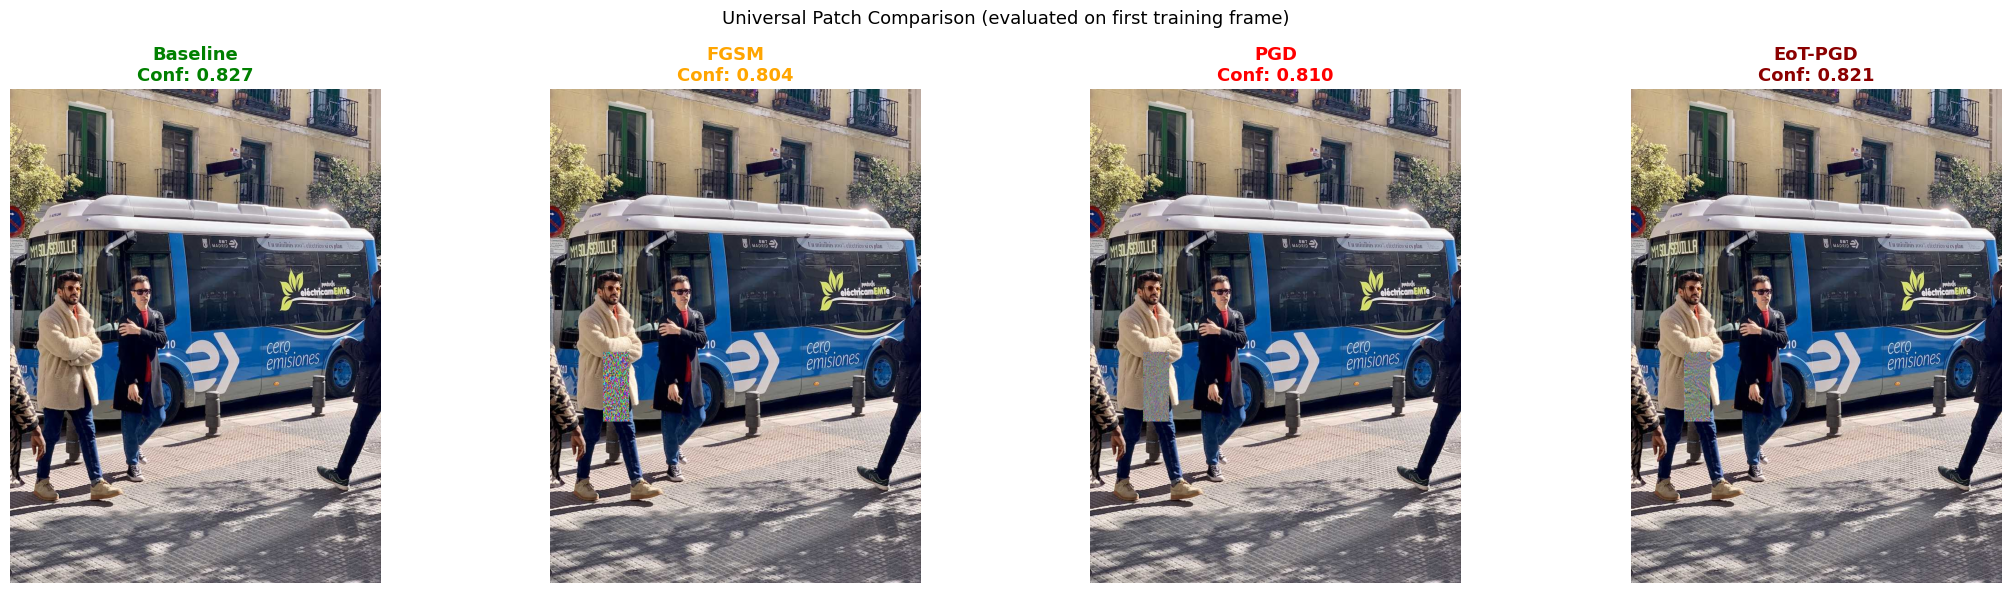

In [28]:
# Summary table
print('\n' + '='*55)
print(f'{"Method":<12} {"Conf":<10} {"Drop":<10} {"% Reduction"}')
print('-'*55)
for label, conf in zip(
    ['Baseline','FGSM','PGD','EoT-PGD'],
    [baseline_conf, fgsm_conf, pgd_conf, eot_conf]
):
    drop = baseline_conf - conf
    pct  = drop/baseline_conf*100 if baseline_conf>0 else 0
    best = ' <-- BEST' if conf==min(fgsm_conf,pgd_conf,eot_conf) else ''
    print(f'{label:<12} {conf:<10.4f} {drop:<10.4f} {pct:.1f}%{best}')
print('='*55)

# Visualize patch applied to first frame
img_rgb = cv2.cvtColor(cv2.imread(FRAME_PATHS[0]), cv2.COLOR_BGR2RGB)
results = baseline_data[FRAME_PATHS[0]][1]
box     = get_shirt_box(results, img_rgb.shape[0], img_rgb.shape[1])

if box:
    img_fgsm_vis = tensor_to_img(apply_patch(img_to_tensor(img_rgb), patch_fgsm, box))
    img_pgd_vis  = tensor_to_img(apply_patch(img_to_tensor(img_rgb), patch_pgd,  box))
    img_eot_vis  = tensor_to_img(apply_patch(img_to_tensor(img_rgb), patch_eot,  box))

    fig, axes = plt.subplots(1,4,figsize=(22,6))
    for ax,img,label,conf,color in zip(
        axes,
        [img_rgb, img_fgsm_vis, img_pgd_vis, img_eot_vis],
        ['Baseline','FGSM','PGD','EoT-PGD'],
        [baseline_conf, fgsm_conf, pgd_conf, eot_conf],
        ['green','orange','red','darkred']
    ):
        ax.imshow(img)
        ax.set_title(f'{label}\nConf: {conf:.3f}', color=color, fontsize=13, fontweight='bold')
        ax.axis('off')
    plt.suptitle('Universal Patch Comparison (evaluated on first training frame)', fontsize=13)
    plt.tight_layout()
    plt.savefig('/content/comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Cell 14: Loss Curves

PGD and EoT-PGD loss over training steps.
Loss going down = patch is getting better at fooling YOLO.

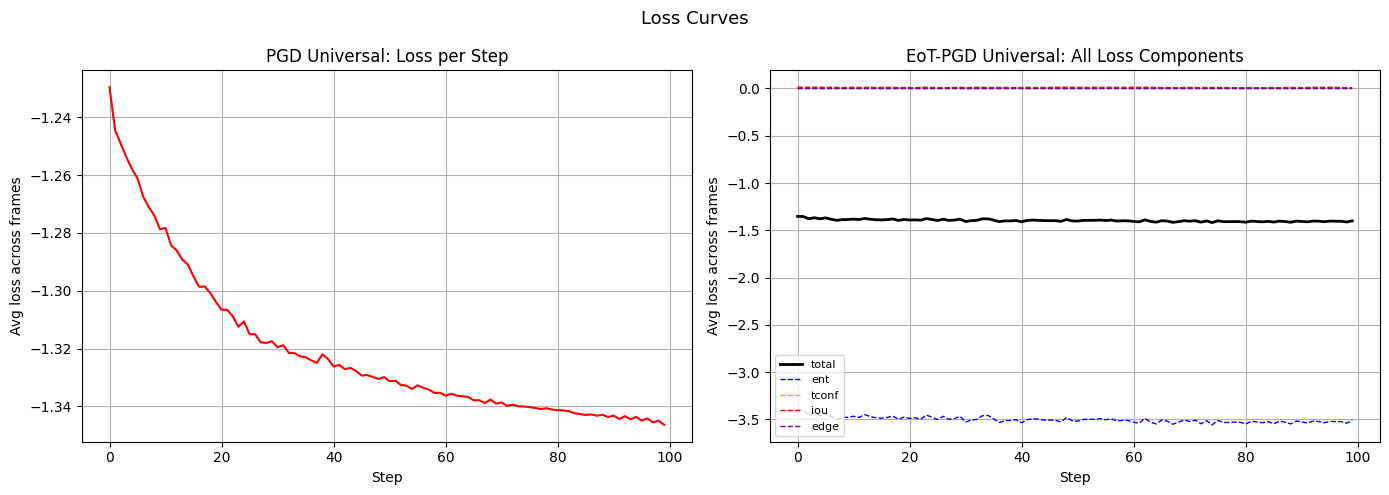

In [29]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].plot(pgd_history, color='red')
axes[0].set_title('PGD Universal: Loss per Step')
axes[0].set_xlabel('Step'), axes[0].set_ylabel('Avg loss across frames')
axes[0].grid(True)

for k,color in zip(['total','ent','tconf','iou','edge'],
                   ['black','blue','orange','red','purple']):
    axes[1].plot(eot_history[k], label=k, color=color,
                 linewidth=2 if k=='total' else 1,
                 linestyle='-' if k=='total' else '--')
axes[1].set_title('EoT-PGD Universal: All Loss Components')
axes[1].set_xlabel('Step'), axes[1].set_ylabel('Avg loss across frames')
axes[1].legend(fontsize=8), axes[1].grid(True)

plt.suptitle('Loss Curves', fontsize=13)
plt.tight_layout()
plt.savefig('/content/loss_curves.png', dpi=150)
plt.show()

---
## Cell 15: Save Patches

Saves all 3 patches as PNG files.
Also saves a 300x300 upscaled version for print preview.

**The EoT-PGD patch is the one to use for physical testing.**

Saved: /content/patch_fgsm.png  (+ 300x300 print preview)
Saved: /content/patch_pgd.png  (+ 300x300 print preview)
Saved: /content/patch_eot.png  (+ 300x300 print preview)


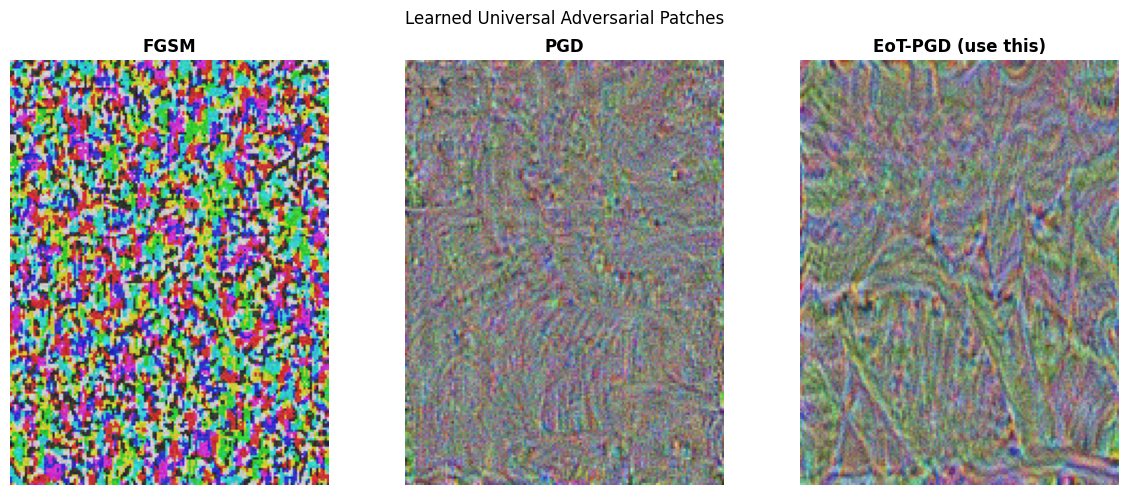


All done. Download patches from the Colab file browser on the left.
Use patch_eot.png for physical testing.


In [30]:
def save_patch(patch_tensor, path):
    p     = patch_tensor.squeeze(0).permute(1,2,0).cpu().detach().numpy()
    p     = (p*255).clip(0,255).astype(np.uint8)
    Image.fromarray(p).save(path)
    large = cv2.resize(p,(300,300),interpolation=cv2.INTER_NEAREST)
    Image.fromarray(large).save(path.replace('.png','_300x300.png'))
    print(f'Saved: {path}  (+ 300x300 print preview)')

save_patch(patch_fgsm, '/content/patch_fgsm.png')
save_patch(patch_pgd,  '/content/patch_pgd.png')
save_patch(patch_eot,  '/content/patch_eot.png')

# Visualize all 3 side by side
fig, axes = plt.subplots(1,3,figsize=(12,5))
for ax,pt,label in zip(axes,
                       [patch_fgsm, patch_pgd, patch_eot],
                       ['FGSM','PGD','EoT-PGD (use this)']):
    p = pt.squeeze(0).permute(1,2,0).cpu().detach().numpy()
    p = (p*255).clip(0,255).astype(np.uint8)
    ax.imshow(cv2.resize(p,(150,200),interpolation=cv2.INTER_NEAREST))
    ax.set_title(label, fontweight='bold')
    ax.axis('off')
plt.suptitle('Learned Universal Adversarial Patches')
plt.tight_layout()
plt.show()
print('\nAll done. Download patches from the Colab file browser on the left.')
print('Use patch_eot.png for physical testing.')